# **Artificial Neural Network**
Artificial Neural Networks (ANNs) are foundational, bio-inspired deep learning models that mimic the human brain to process data through interconnected nodes (neurons). They consist of input, hidden, and output layers, learning complex, non-linear relationships by optimizing weight connections via training. ANNs are used for image, text, and predictive analysis

![](https://media.geeksforgeeks.org/wp-content/cdn-uploads/20230602113310/Neural-Networks-Architecture.png)

## Working

All the work in an ANN is done in the hidden layers, here we are *assuming* that we have an ANN with:
- 3 input features and 1 output feature
- 2 hidden layers

### **Step 1**: Initalisation
Firstly we initialse the **weights** and **bais** of the neurons. The weights are denoted as $w_0, w_1$ and $w_2$.

### **Step 2**: Calculations in the hidden layers
Each neuron gets some values based on this equation:
$$ z = w_0*x_0 + w_1*x_1 + w_2*x_2 + b$$
$$ b = bais $$
$$ ẑ = a(z) $$
$$ a(z) = \text{Activation function} $$

Now these values are treated as **inputs** of the next layer, and this process continues till all the layers are done with there work, in this example we have only two layers.

### **Step 3**: Calculate Loss
Now the loss is calculated with the actual output

$$ loss(ŷ) = |y - ŷ| $$

### **Step 4**: Backpropogation:
Based on the loss, The model goes backward to update the weights and bais, so the loss becomes minimum.

### **Step 5**: Repeat
All these steps are repeated untill the loss is minimised.

## Back-propogation
Backpropagation (backward propagation of errors) is the fundamental algorithm used to train artificial neural networks by adjusting the model's weights and biases to minimize prediction errors.

$$ \text{Weights updation} $$
$$ w_{new} = w_{old} + ɳ(\frac{∂l}{∂w_{old}}) $$
$$ ɳ = \text{Learning rate} $$
$$ \frac{∂l}{∂w_{old}} = \text{Derivative of loss with respect of }w_{old} $$

## Implementation

In [37]:
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [59]:
# load out dataset

from sklearn.datasets import make_classification

X, y = make_classification(n_features=20, n_classes=2, n_samples=2000)
X, y

(array([[ 0.71633678,  0.90287978, -0.17062063, ...,  1.03016783,
          0.23337424, -0.54897501],
        [ 0.58448103,  0.30684102,  0.72893414, ...,  1.2428913 ,
         -0.72920912,  0.40977394],
        [ 0.05957347,  2.28623447,  0.16029739, ..., -0.30802511,
         -0.77819717, -0.88639416],
        ...,
        [-0.20975432, -0.11324824,  2.006339  , ..., -0.85478135,
         -0.71683802,  0.4088376 ],
        [ 0.2529567 ,  2.30645239,  0.34735216, ...,  0.43369319,
          0.99909903, -1.43992062],
        [-0.21219755,  0.46887374, -0.65142896, ..., -0.75366548,
          1.37386677, -1.89281261]]),
 array([0, 1, 1, ..., 1, 0, 0]))

In [60]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.716337,0.902880,-0.170621,0.116324,-1.107588,0.947760,0.408480,-0.173362,0.096986,1.203910,-1.030883,0.301894,-0.367155,-0.061304,1.254916,0.316758,0.197137,1.030168,0.233374,-0.548975
1,0.584481,0.306841,0.728934,-0.640369,0.012238,-0.649878,0.777748,-0.044104,-0.134730,0.794238,1.657811,0.988706,0.278200,-0.060797,-0.265853,-0.714131,1.043839,1.242891,-0.729209,0.409774
2,0.059573,2.286234,0.160297,-1.840337,0.179369,-1.056489,1.732924,-0.451937,-0.872577,-1.115585,1.475509,1.691098,0.670685,1.920267,-0.169130,-0.804368,0.371031,-0.308025,-0.778197,-0.886394
3,-0.463923,-1.226749,0.032078,-0.005423,0.359098,-0.480074,0.347472,-0.074964,0.395337,-1.218974,-0.185019,0.361742,-0.846249,-1.123654,-0.391633,-0.477634,-0.119359,-0.614520,-1.496718,-0.098085
4,1.458735,0.403299,-0.809663,0.374933,-0.544752,-1.058497,-0.617903,0.578212,0.583411,-0.247095,-0.905524,0.000633,-0.189460,-1.115344,0.122016,0.233164,1.706539,-0.612389,0.912676,2.438044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.059065,0.713447,0.097874,0.422512,0.894786,-0.787987,0.455148,-0.334851,-0.859074,0.374300,0.016088,0.131326,-0.821603,-0.779314,-0.528129,-0.420496,1.153962,-1.363252,-0.262732,-1.332560
1996,0.914858,1.105578,1.874815,-0.232506,1.396463,0.024290,-0.186526,0.244819,-1.126871,0.731855,-0.501388,0.101900,0.594807,0.122562,0.712214,-0.056446,0.359296,1.137994,0.982216,1.093518
1997,-0.209754,-0.113248,2.006339,1.425074,-0.074673,1.827502,-0.412427,0.146451,0.671551,1.826657,-0.747709,-0.346184,1.244345,1.034454,0.539696,0.188962,-1.029136,-0.854781,-0.716838,0.408838
1998,0.252957,2.306452,0.347352,0.544252,-0.424193,-1.641320,0.703480,-0.395750,-0.174526,0.006452,-1.418053,0.379257,0.066229,-0.316612,-1.055369,-0.965131,1.299661,0.433693,0.999099,-1.439921


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [64]:
X_train.shape

(1600, 20)

In [65]:
# make a neural network (ANN)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LeakyReLU, ReLU, PReLU, ELU, Dropout, Dense

In [66]:
classifier = Sequential()

In [67]:
# make layers

classifier.add(Dense(units=20, activation='relu'))  # input layer (30 features)
classifier.add(Dense(units=12, activation='relu'))  # first hidden layer
classifier.add(Dense(units=7, activation='relu'))  # second hidden layer
classifier.add(Dense(units=3, activation='relu'))   # third hidden layer
classifier.add(Dense(1, activation='sigmoid'))   # output layer

In [68]:
# defining own learning rate

opt = tf.keras.optimizers.Adam(learning_rate=0.01)

In [69]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [71]:
model_hist = classifier.fit(X_train, y_train, validation_split=0.3, batch_size=10, epochs=50)

Epoch 1/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9806 - loss: 0.0435 - val_accuracy: 0.8771 - val_loss: 0.5647
Epoch 2/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9906 - loss: 0.0275 - val_accuracy: 0.8792 - val_loss: 0.5413
Epoch 3/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9870 - loss: 0.0313 - val_accuracy: 0.8958 - val_loss: 0.7035
Epoch 4/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9860 - loss: 0.0242 - val_accuracy: 0.8979 - val_loss: 0.7141
Epoch 5/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9806 - loss: 0.0293 - val_accuracy: 0.8938 - val_loss: 0.8402
Epoch 6/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9933 - loss: 0.0165 - val_accuracy: 0.8750 - val_loss: 0.7999
Epoch 7/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9869 - loss: 0.0389 - val_accuracy: 0.8813 - val_loss: 0.6756
Epoch 8/50
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9749 - loss: 0.0614 - val_accuracy: 0.

In [84]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)
y_pred

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [

0.9175
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       186
           1       0.93      0.91      0.92       214

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

[[172  14]
 [ 19 195]]


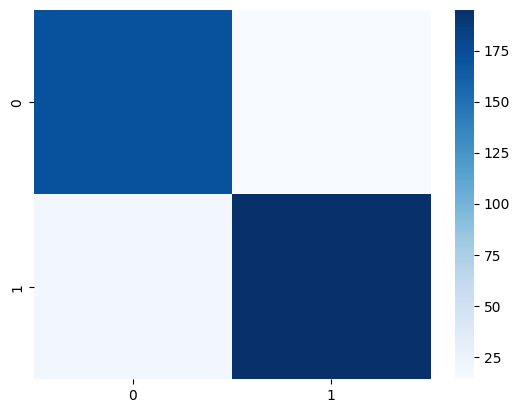

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

print(accuracy_score(y_pred=y_pred, y_true=y_test))
print(classification_report(y_pred=y_pred, y_true=y_test))
print(confusion_matrix(y_pred=y_pred, y_true=y_test))
sns.heatmap(confusion_matrix(y_pred=y_pred, y_true=y_test), cmap='Blues')
plt.show()